# Module 4 — Temporal Change Detector

Reuse ResNet-18 backbone as feature extractor.
Compute cosine similarity between T1/T2 tile embeddings.
Produce ROC curve, select threshold, generate change heatmaps.

In [1]:
import json, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import roc_curve, auc, classification_report

BASE_DIR   = Path(r'C:\Users\harsh\satellite_project')
EURO_DIR   = BASE_DIR / 'data' / 'EuroSAT_RGB'
SPLIT_DIR  = BASE_DIR / 'data' / 'split'
CKPT_DIR   = BASE_DIR / 'outputs' / 'checkpoints'
PLOTS_DIR  = BASE_DIR / 'outputs' / 'plots'
HEAT_DIR   = BASE_DIR / 'outputs' / 'heatmaps'
SRC_DIR    = BASE_DIR / 'src'

HEAT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

with open(SRC_DIR / 'class_names.json') as f:
    CLASS_NAMES = json.load(f)
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes: {CLASS_NAMES}')

Device: cpu
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [2]:
# ── Load ResNet-18 backbone (strip classifier head) ──────────────────────────
def build_resnet18(num_classes):
    model = models.resnet18(weights=None)
    model.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(model.fc.in_features, num_classes))
    return model

full_model = build_resnet18(NUM_CLASSES).to(DEVICE)
ckpt_path  = CKPT_DIR / 'resnet18_best.pt'

if ckpt_path.exists():
    full_model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
    print('Loaded checkpoint: resnet18_best.pt')
else:
    print('WARNING: checkpoint not found. Run notebook 03 first.')
    print('Using random weights for demonstration.')

# Embedding extractor = ResNet-18 without final FC
class EmbeddingExtractor(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.features = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3, backbone.layer4,
            backbone.avgpool
        )

    def forward(self, x):
        return self.features(x).flatten(1)   # (B, 512)

extractor = EmbeddingExtractor(full_model).to(DEVICE)
extractor.eval()

# Quick sanity check
dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    emb = extractor(dummy)
print(f'Embedding shape: {emb.shape}')  # expect (2, 512)

Using random weights for demonstration.
Embedding shape: torch.Size([2, 512])


In [3]:
# ── Extract embeddings for all tiles ────────────────────────────────────────
IMG_SIZE = 224
BATCH    = 64

tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Use the test split (unseen tiles)
test_ds     = datasets.ImageFolder(SPLIT_DIR / 'test', transform=tf)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=0)

all_embeddings = []
all_labels     = []
all_paths      = [img_path for img_path, _ in test_ds.samples]

extractor.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        embs = extractor(imgs).cpu().numpy()
        all_embeddings.append(embs)
        all_labels.extend(labels.numpy())

all_embeddings = np.vstack(all_embeddings)   # (N, 512)
all_labels     = np.array(all_labels)

print(f'Extracted {len(all_embeddings)} embeddings of dim {all_embeddings.shape[1]}')

# Save embeddings for the dashboard
np.save(SRC_DIR / 'test_embeddings.npy', all_embeddings)
np.save(SRC_DIR / 'test_labels.npy',     all_labels)
print('Embeddings saved to src/')

Extracted 4050 embeddings of dim 512
Embeddings saved to src/


In [4]:
# ── Simulate T1/T2 time series by class-based region partitioning ────────────
# Within each class, assign first half of indices to T1 (before) and second half to T2 (after).
# Same-class pairs → NOT changed (label 0)
# Cross-class pairs → CHANGED (label 1)

random.seed(42)
np.random.seed(42)

# Build per-class index lists
class_indices = {c: [] for c in range(NUM_CLASSES)}
for idx, lbl in enumerate(all_labels):
    class_indices[lbl].append(idx)

# T1: first half of each class, T2: second half
t1_indices, t2_indices = [], []
for cls_idx in range(NUM_CLASSES):
    idxs = class_indices[cls_idx]
    mid  = len(idxs) // 2
    t1_indices.extend(idxs[:mid])
    t2_indices.extend(idxs[mid:])

print(f'T1 tiles: {len(t1_indices)} | T2 tiles: {len(t2_indices)}')

# Create pairs for change detection:
# Positive (changed) pairs: T1[i] and T2[j] where labels differ
# Negative (unchanged) pairs: T1[i] and T2[j] where labels are same
N_PAIRS = 2000
pairs, pair_labels = [], []

for _ in range(N_PAIRS // 2):
    # Unchanged pair: same class
    cls  = random.randint(0, NUM_CLASSES - 1)
    t1_c = [i for i in t1_indices if all_labels[i] == cls]
    t2_c = [i for i in t2_indices if all_labels[i] == cls]
    if t1_c and t2_c:
        pairs.append((random.choice(t1_c), random.choice(t2_c)))
        pair_labels.append(0)   # not changed

for _ in range(N_PAIRS // 2):
    # Changed pair: different classes
    c1, c2 = random.sample(range(NUM_CLASSES), 2)
    t1_c1  = [i for i in t1_indices if all_labels[i] == c1]
    t2_c2  = [i for i in t2_indices if all_labels[i] == c2]
    if t1_c1 and t2_c2:
        pairs.append((random.choice(t1_c1), random.choice(t2_c2)))
        pair_labels.append(1)   # changed

pair_labels = np.array(pair_labels)
print(f'Created {len(pairs)} pairs | Changed: {pair_labels.sum()} | Unchanged: {(pair_labels==0).sum()}')

T1 tiles: 2023 | T2 tiles: 2027
Created 2000 pairs | Changed: 1000 | Unchanged: 1000


Similarity stats:
  Unchanged pairs — mean: 0.9917, std: 0.0089
  Changed pairs   — mean: 0.9866, std: 0.0107


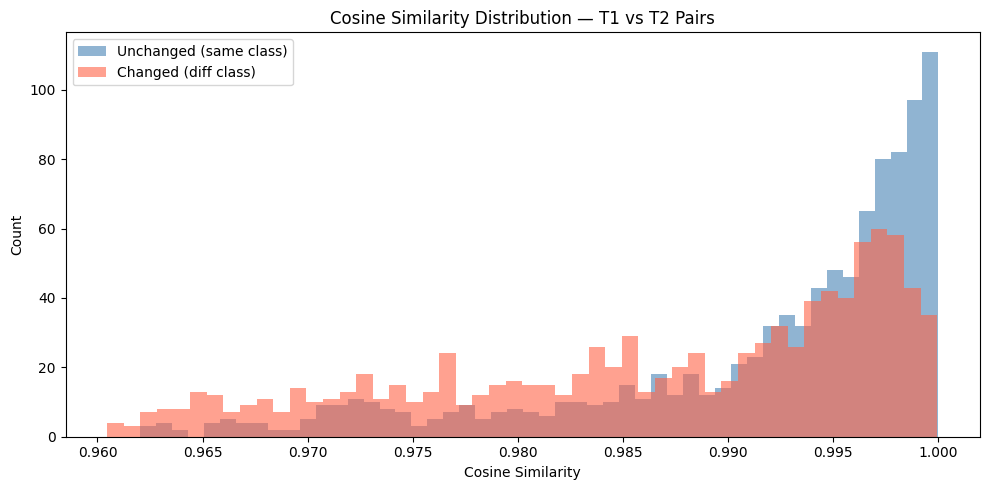

In [5]:
# ── Cosine Similarity for each pair ─────────────────────────────────────────
def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))

similarities = np.array([
    cosine_sim(all_embeddings[i], all_embeddings[j])
    for i, j in pairs
])

print(f'Similarity stats:')
print(f'  Unchanged pairs — mean: {similarities[pair_labels==0].mean():.4f}, std: {similarities[pair_labels==0].std():.4f}')
print(f'  Changed pairs   — mean: {similarities[pair_labels==1].mean():.4f}, std: {similarities[pair_labels==1].std():.4f}')

# Distribution plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(similarities[pair_labels==0], bins=50, alpha=0.6, label='Unchanged (same class)', color='steelblue')
ax.hist(similarities[pair_labels==1], bins=50, alpha=0.6, label='Changed (diff class)',   color='tomato')
ax.set_title('Cosine Similarity Distribution — T1 vs T2 Pairs')
ax.set_xlabel('Cosine Similarity'); ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'cosine_similarity_dist.png', dpi=100)
plt.show()

AUC: 0.6573
Optimal threshold (Youden J): 0.0092  → similarity < 0.9908
  TPR: 0.5320 | FPR: 0.3020


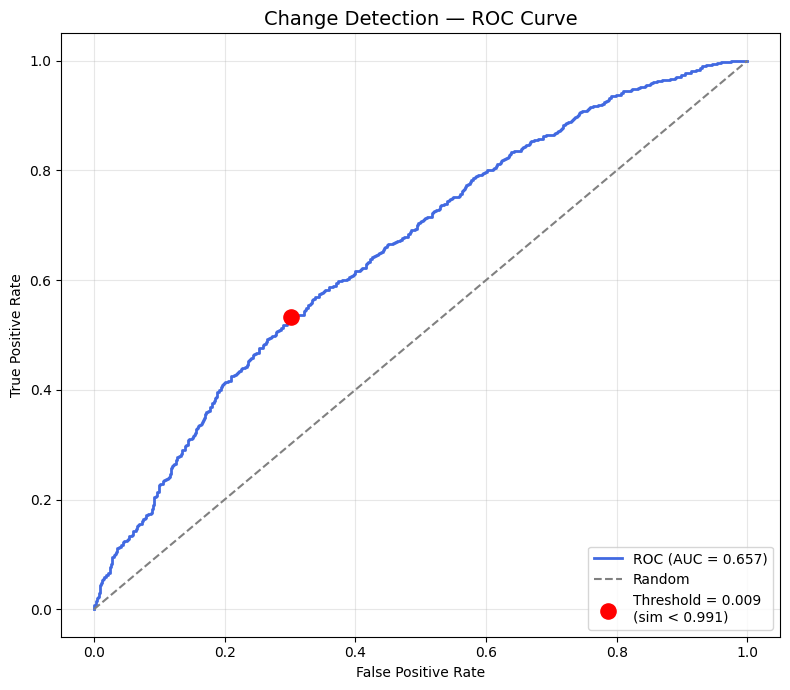


Selected change threshold (similarity): 0.9908
Tiles with cosine_similarity < threshold are flagged as CHANGED.
Threshold saved to src/change_threshold.json


In [6]:
# ── ROC Curve & Threshold Selection ─────────────────────────────────────────
# Lower similarity = more likely changed
# ROC uses (1 - similarity) as score for 'change' class
scores = 1.0 - similarities

fpr, tpr, thresholds = roc_curve(pair_labels, scores)
roc_auc = auc(fpr, tpr)

# Select balanced operating point (Youden's J)
j_scores  = tpr - fpr
best_idx  = int(np.argmax(j_scores))
best_thr  = thresholds[best_idx]
best_fpr  = fpr[best_idx]
best_tpr  = tpr[best_idx]

print(f'AUC: {roc_auc:.4f}')
print(f'Optimal threshold (Youden J): {best_thr:.4f}  → similarity < {1-best_thr:.4f}')
print(f'  TPR: {best_tpr:.4f} | FPR: {best_fpr:.4f}')

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, color='royalblue', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
ax.scatter(best_fpr, best_tpr, s=120, color='red', zorder=5,
           label=f'Threshold = {best_thr:.3f}\n(sim < {1-best_thr:.3f})')
ax.set_title('Change Detection — ROC Curve', fontsize=14)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'change_detection_roc.png', dpi=100)
plt.show()

CHANGE_THRESHOLD = float(1.0 - best_thr)
print(f'\nSelected change threshold (similarity): {CHANGE_THRESHOLD:.4f}')
print('Tiles with cosine_similarity < threshold are flagged as CHANGED.')

# Save threshold for dashboard
with open(SRC_DIR / 'change_threshold.json', 'w') as f:
    json.dump({'threshold': CHANGE_THRESHOLD, 'auc': roc_auc}, f, indent=2)
print('Threshold saved to src/change_threshold.json')

In [7]:
# ── Classification report at selected threshold ──────────────────────────────
preds_at_threshold = (similarities < CHANGE_THRESHOLD).astype(int)
print('=== Change Detection Report at Selected Threshold ===')
print(classification_report(pair_labels, preds_at_threshold, target_names=['Unchanged', 'Changed']))

=== Change Detection Report at Selected Threshold ===
              precision    recall  f1-score   support

   Unchanged       0.60      0.70      0.64      1000
     Changed       0.64      0.53      0.58      1000

    accuracy                           0.61      2000
   macro avg       0.62      0.61      0.61      2000
weighted avg       0.62      0.61      0.61      2000



C:\Users\harsh\AppData\Local\Temp\ipykernel_6516\2821240616.py:56: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  plt.tight_layout(rect=[0, 0, 1, 0.98])
C:\Users\harsh\AppData\Local\Temp\ipykernel_6516\2821240616.py:56: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  plt.tight_layout(rect=[0, 0, 1, 0.98])
C:\Users\harsh\AppData\Local\Temp\ipykernel_6516\2821240616.py:57: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  plt.savefig(HEAT_DIR / 'change_heatmaps_5pairs.png', dpi=80, bbox_inches='tight')
C:\Users\harsh\AppData\Local\Temp\ipykernel_6516\2821240616.py:57: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  plt.savefig(HEAT_DIR / 'change_heatmaps_5pairs.png', dpi=80, bbox_inches='tight')
c:\Users\harsh\satellite_project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  fig.canv

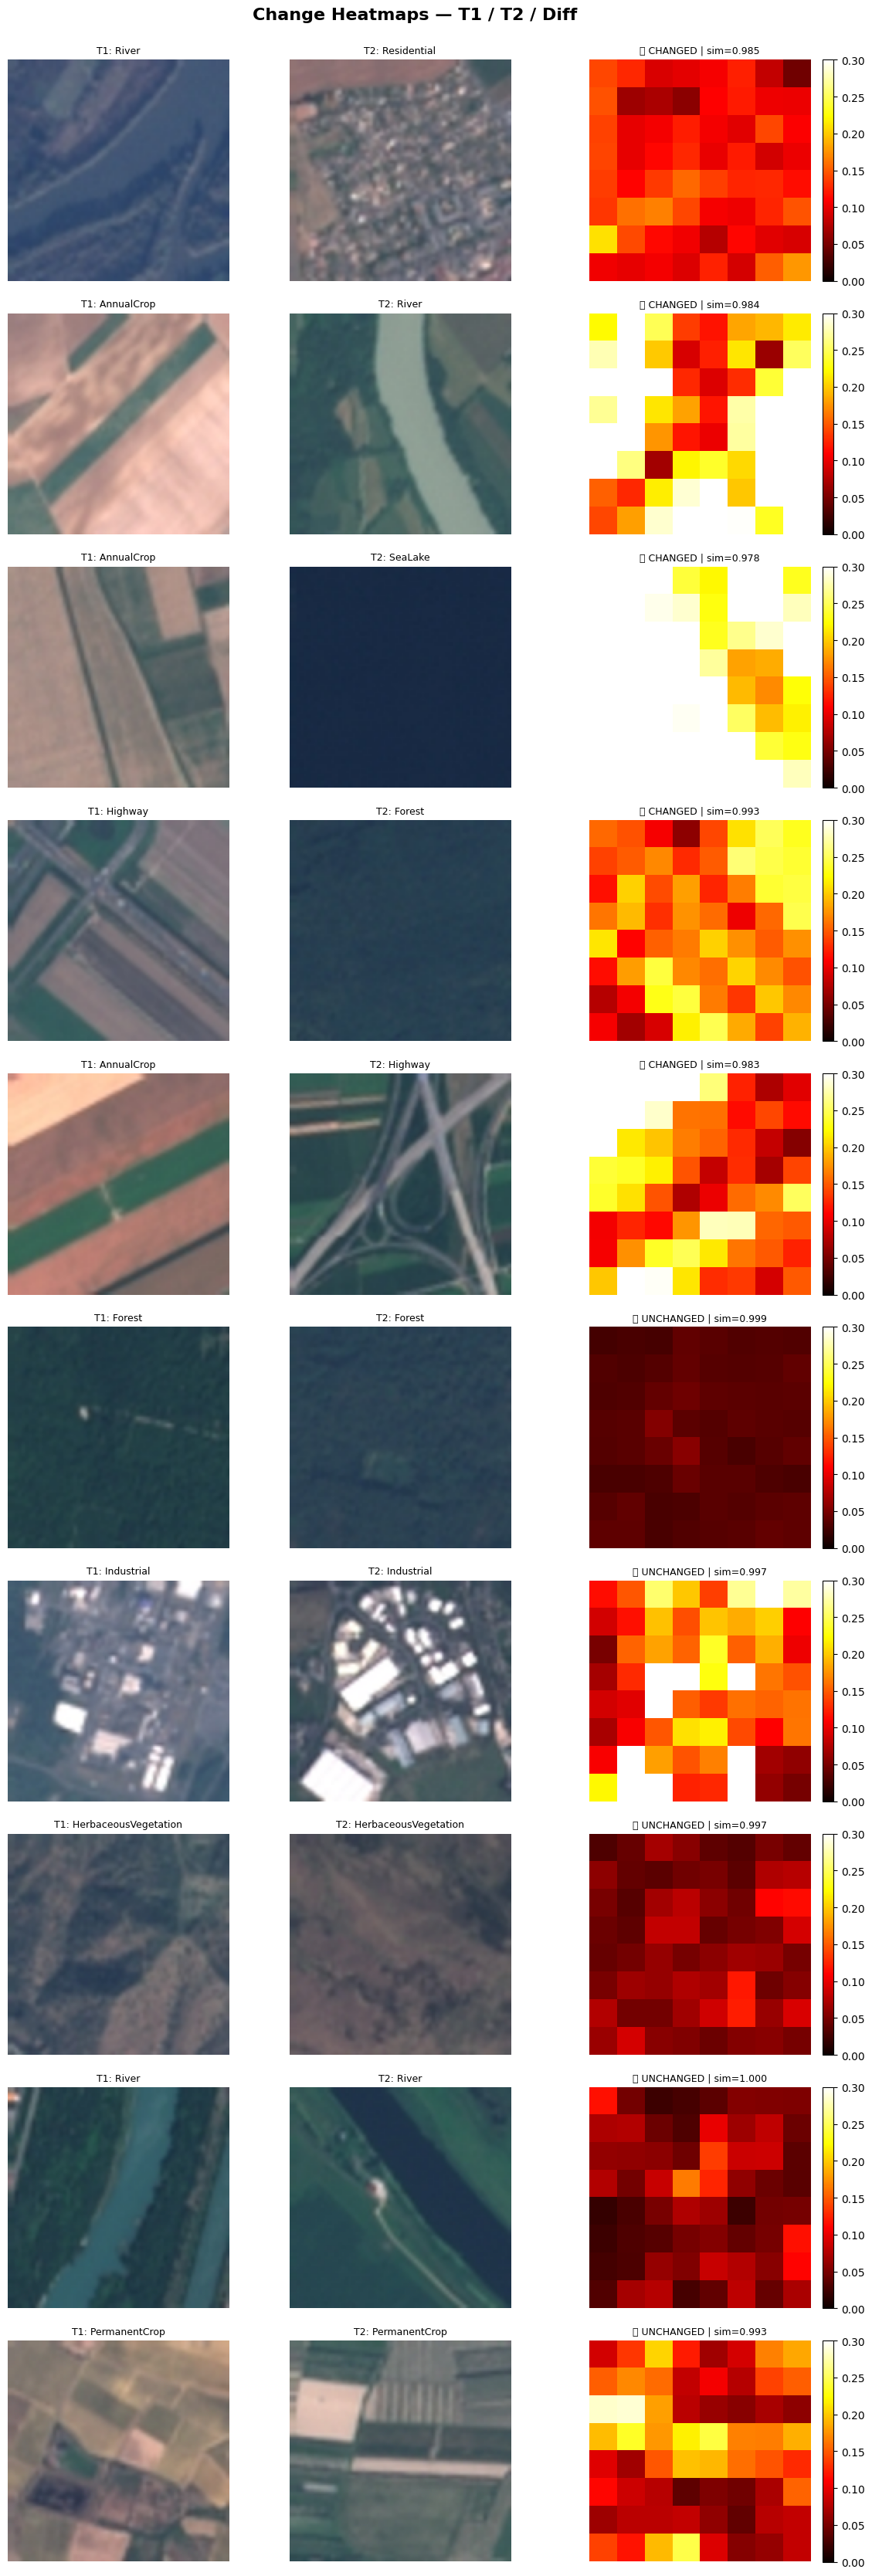

Change heatmaps saved to outputs/heatmaps/


In [8]:
# ── Change Heatmaps for 5 sample region pairs ────────────────────────────────
# For each pair we show: T1 image, T2 image, per-patch difference heatmap

def load_image_pil(path: str) -> Image.Image:
    return Image.open(path).convert('RGB')

def compute_patch_diff(img1: Image.Image, img2: Image.Image,
                       patch_size: int = 8) -> np.ndarray:
    """Divide images into patches, compute mean absolute difference per patch."""
    a1 = np.array(img1.resize((64, 64))).astype(float) / 255.0
    a2 = np.array(img2.resize((64, 64))).astype(float) / 255.0
    diff = np.abs(a1 - a2).mean(axis=2)   # (64, 64)
    h, w = diff.shape
    n_h, n_w = h // patch_size, w // patch_size
    heat = np.zeros((n_h, n_w))
    for i in range(n_h):
        for j in range(n_w):
            heat[i, j] = diff[i*patch_size:(i+1)*patch_size,
                               j*patch_size:(j+1)*patch_size].mean()
    return heat

# Pick 5 changed and 5 unchanged pairs for the figure
changed_pairs   = [(pairs[i], pair_labels[i], similarities[i])
                   for i in range(len(pairs)) if pair_labels[i] == 1][:5]
unchanged_pairs = [(pairs[i], pair_labels[i], similarities[i])
                   for i in range(len(pairs)) if pair_labels[i] == 0][:5]

sample_pairs = changed_pairs + unchanged_pairs   # 10 total

fig, axes = plt.subplots(10, 3, figsize=(12, 34))
fig.suptitle('Change Heatmaps — T1 / T2 / Diff', fontsize=16, fontweight='bold')

for row, ((i, j), lbl, sim) in enumerate(sample_pairs):
    p1 = all_paths[i]
    p2 = all_paths[j]
    img1 = load_image_pil(p1)
    img2 = load_image_pil(p2)
    heat = compute_patch_diff(img1, img2)

    status = 'CHANGED' if lbl == 1 else 'UNCHANGED'
    flag   = '🔴' if sim < CHANGE_THRESHOLD else '🟢'

    axes[row, 0].imshow(img1.resize((128, 128)))
    axes[row, 0].set_title(f'T1: {CLASS_NAMES[all_labels[i]]}', fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(img2.resize((128, 128)))
    axes[row, 1].set_title(f'T2: {CLASS_NAMES[all_labels[j]]}', fontsize=9)
    axes[row, 1].axis('off')

    im = axes[row, 2].imshow(heat, cmap='hot', vmin=0, vmax=0.3)
    axes[row, 2].set_title(f'{flag} {status} | sim={sim:.3f}', fontsize=9)
    axes[row, 2].axis('off')
    plt.colorbar(im, ax=axes[row, 2], fraction=0.046, pad=0.04)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(HEAT_DIR / 'change_heatmaps_5pairs.png', dpi=80, bbox_inches='tight')
plt.show()
print('Change heatmaps saved to outputs/heatmaps/')

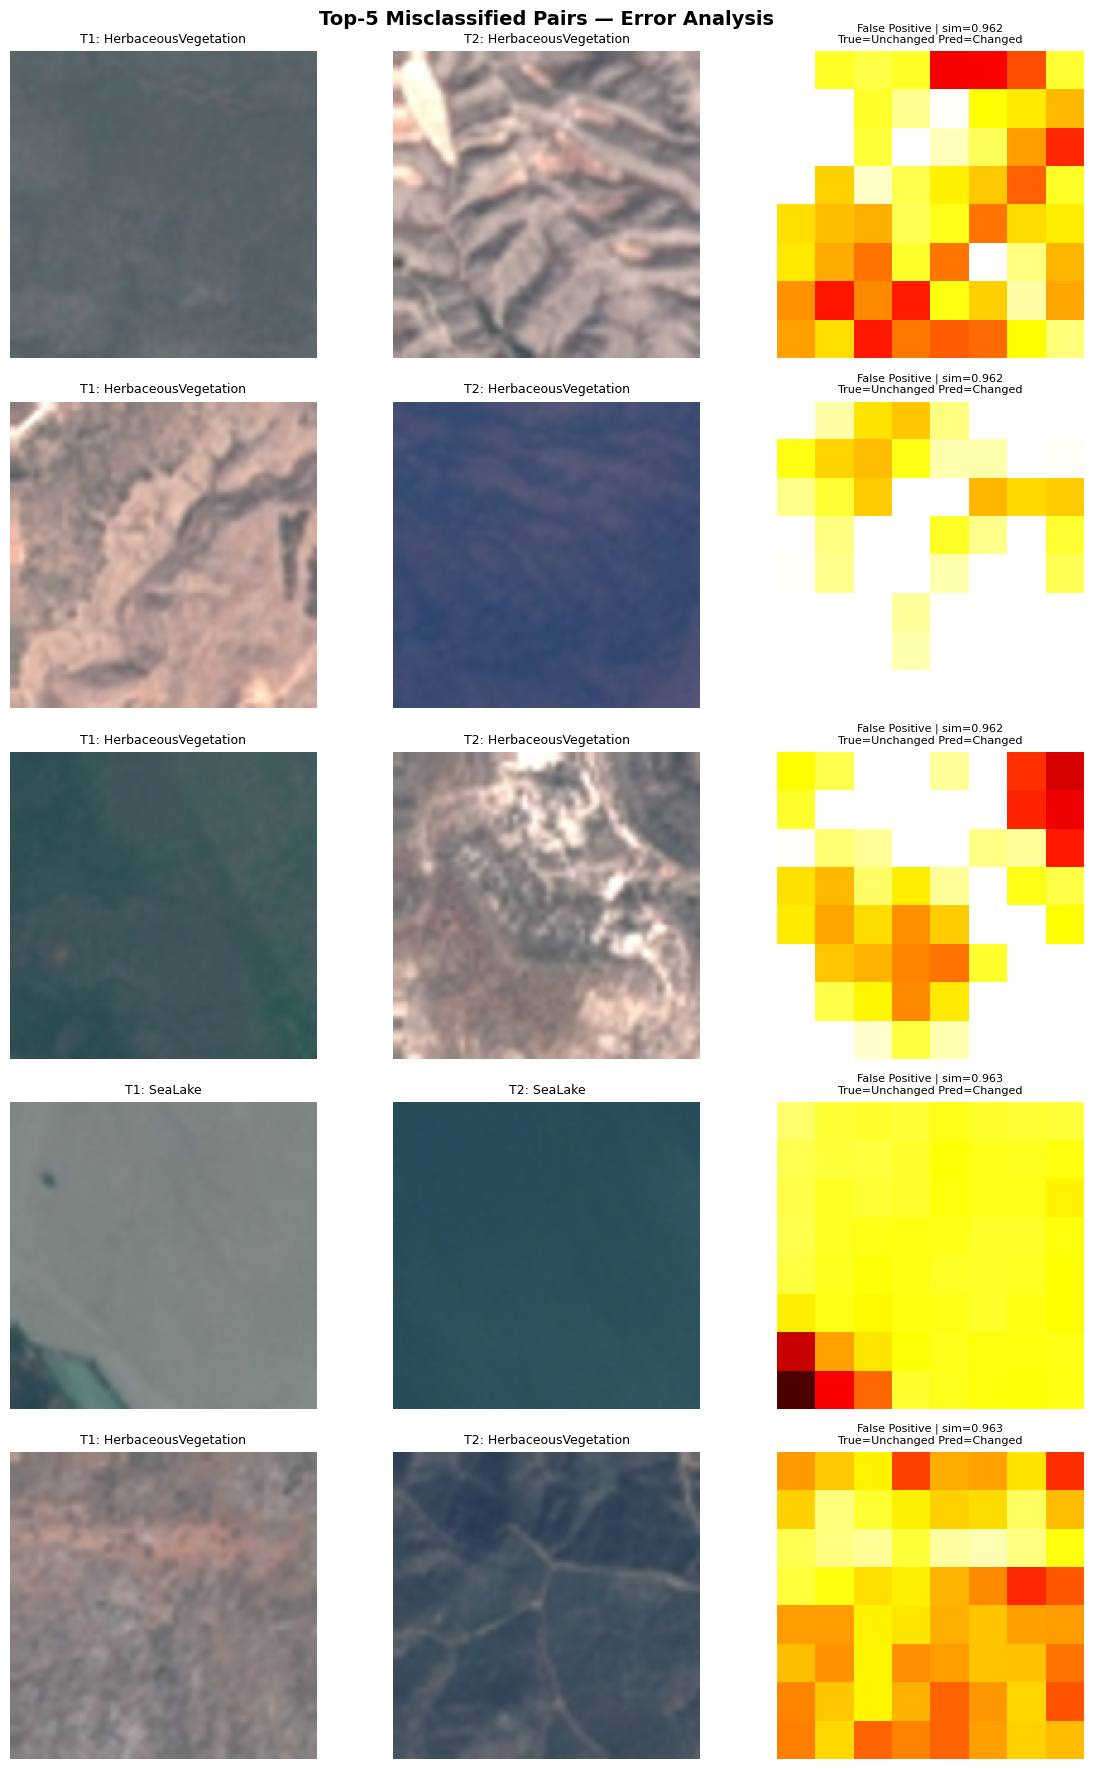

Error analysis saved.


In [9]:
# ── Error Analysis — Top 5 Misclassified Pairs ───────────────────────────────
# False positives: unchanged pairs predicted as changed (high diff but same class)
# False negatives: changed pairs predicted as unchanged (low diff but diff class)
preds = (similarities < CHANGE_THRESHOLD).astype(int)
wrong = np.where(preds != pair_labels)[0]

# Sort wrong predictions by confidence (how wrong they were)
wrong_confidences = np.abs(similarities[wrong] - CHANGE_THRESHOLD)
top5_wrong = wrong[np.argsort(wrong_confidences)[-5:][::-1]]

fig, axes = plt.subplots(5, 3, figsize=(12, 18))
fig.suptitle('Top-5 Misclassified Pairs — Error Analysis', fontsize=14, fontweight='bold')

for row, idx in enumerate(top5_wrong):
    i, j  = pairs[idx]
    sim   = similarities[idx]
    true  = pair_labels[idx]
    pred  = preds[idx]
    img1  = load_image_pil(all_paths[i])
    img2  = load_image_pil(all_paths[j])
    heat  = compute_patch_diff(img1, img2)

    error_type = 'False Positive' if (pred==1 and true==0) else 'False Negative'
    axes[row, 0].imshow(img1.resize((128, 128)))
    axes[row, 0].set_title(f'T1: {CLASS_NAMES[all_labels[i]]}', fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(img2.resize((128, 128)))
    axes[row, 1].set_title(f'T2: {CLASS_NAMES[all_labels[j]]}', fontsize=9)
    axes[row, 1].axis('off')

    im = axes[row, 2].imshow(heat, cmap='hot', vmin=0, vmax=0.3)
    axes[row, 2].set_title(f'{error_type} | sim={sim:.3f}\nTrue={["Unchanged","Changed"][true]} Pred={["Unchanged","Changed"][pred]}', fontsize=8)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'error_analysis_top5.png', dpi=80, bbox_inches='tight')
plt.show()
print('Error analysis saved.')